# Stage 5 — Predictive maintenance: which fault is developing

## What this dataset can and cannot support

A predictive-maintenance system can target one of two things:

1. **Failure classification** — will this machine fail, and how?
2. **Remaining useful life (RUL)** — how many cycles until it fails?

RUL regression needs **run-to-failure trajectories**: the same unit tracked over
time until it dies, so that "cycles remaining" is observable. AI4I has no such
structure — each row is an independent snapshot of one cycle, with no unit
identity carried across rows. `Tool wear [min]` looks like a clock, but there is
no trajectory linking one row to the next.

So this project does **not** claim RUL. Manufacturing one from the tool-wear
threshold would be circular: the "remaining life" would just be
`240 − tool_wear`, which is arithmetic dressed up as a model. A real RUL study
needs NASA C-MAPSS or comparable run-to-failure data.

What this dataset *does* support, and what this stage builds, is **fault-mode
diagnosis**: given that a failure is indicated, which physical mode is
developing. That is what turns an alarm into a work order.

## Formulation

- **Multi-label**, not multi-class: 23 of the usable failures carry two or more
  modes simultaneously, most often power together with overstrain
- One **binary head per mode** (TWF, HDF, PWF, OSF), so each fault gets an
  independent probability and co-occurrence is represented honestly
- **Conditional on failure**: trained and evaluated only on rows with a recorded
  failure carrying at least one physical mode flag
- **RNF excluded**, along with the 9 failures that have no mode flag — no sensor
  signature means nothing to learn


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg, data, features, eda, models, evaluate, anomaly, explain, viz
viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


In [2]:
df = features.add_physics_features(data.add_targets(data.load_raw()))
train_df, test_df = data.stratified_split(df)

train_modes, Y_train = data.mode_target_matrix(train_df)
test_modes,  Y_test  = data.mode_target_matrix(test_df)
Xm_train = features.X_frame(train_modes)
Xm_test  = features.X_frame(test_modes)

print(f"mode-eligible rows: {len(train_modes)} train / {len(test_modes)} test")
print(f"(from {int(train_df.y_failure.sum())} / {int(test_df.y_failure.sum())} total failures)")
print()
print("per-mode positives:")
pd.DataFrame({"train": Y_train.sum(), "test": Y_test.sum()})

mode-eligible rows: 264 train / 66 test
(from 271 / 68 total failures)

per-mode positives:


,train,test
TWF,36,10
HDF,93,22
PWF,75,20
OSF,78,20


These are small numbers — 36 training examples for tool-wear failure — and that
shapes how the results should be read. Cross-validation is reported as the
primary estimate because a held-out split of 66 rows across four modes is too
thin to be stable on its own.


In [3]:
from sklearn.base import clone
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

def single_head():
    return Pipeline([
        ("prep", features.build_preprocessor(scale_numeric=False)),
        ("clf", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.08,
                              subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                              objective="binary:logistic", eval_metric="logloss",
                              tree_method="hist", n_jobs=-1,
                              random_state=cfg.RANDOM_STATE)),
    ])

rows = []
for code_ in cfg.MODE_COLS_MODELLED:
    y_m = Y_train[code_].to_numpy()
    skf = StratifiedKFold(n_splits=min(5, int(y_m.sum())), shuffle=True,
                          random_state=cfg.RANDOM_STATE)
    p_oof = cross_val_predict(single_head(), Xm_train, y_m, cv=skf,
                              method="predict_proba")[:, 1]
    rows.append({
        "mode": code_,
        "fault": cfg.MODE_LABELS[code_],
        "train_positives": int(y_m.sum()),
        "cv_pr_auc": round(float(average_precision_score(y_m, p_oof)), 4),
        "cv_roc_auc": round(float(roc_auc_score(y_m, p_oof)), 4),
    })
mode_table = pd.DataFrame(rows)
mode_table

,mode,fault,train_positives,cv_pr_auc,cv_roc_auc
0,TWF,Tool wear failure,36,0.8887,0.9739
1,HDF,Heat dissipation failure,93,0.9984,0.9991
2,PWF,Power failure,75,1.0000,1.0000
3,OSF,Overstrain failure,78,0.9924,0.9971


### Reading these numbers honestly

Heat dissipation, power and overstrain are diagnosed close to perfectly. That
deserves an explanation rather than a victory lap.

The reason is structural: AI4I's fault modes were *defined* by threshold rules
over the physical quantities computed in Stage 2. A power failure is recorded
when mechanical power leaves its band — and mechanical power is a feature. So
the model is not solving a hard inference problem here; it is recovering a
threshold on a quantity it can see directly.

That is not leakage of the labels — no rule, flag or threshold was fed in, and
the model had to find the cut points itself. But it does mean **the fault-mode
numbers are not the right measure of this project's difficulty.** The binary
stage is, and it lands at PR-AUC ≈ 0.88 rather than ≈ 1.0, because the binary
target also contains unexplainable failures and per-variant overstrain limits.

Tool wear scores lowest, and that is the informative case: TWF has the fewest
examples (36) and its rule includes a stochastic element, so it is the one mode
with genuine irreducible difficulty.


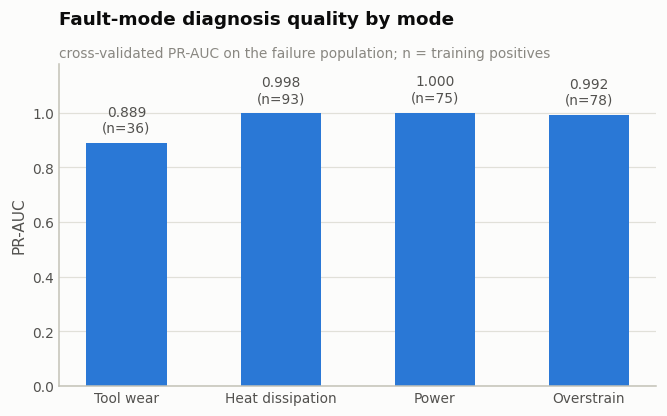

In [4]:
ax_data = mode_table
fig, ax = plt.subplots(figsize=(7.0, 3.8))
xs = np.arange(len(ax_data))
ax.bar(xs, ax_data["cv_pr_auc"], width=0.52, color=viz.SERIES[0])
for x, v, n in zip(xs, ax_data["cv_pr_auc"], ax_data["train_positives"]):
    ax.text(x, v + 0.03, f"{v:.3f}\n(n={n})", ha="center", va="bottom",
            fontsize=9, color=viz.INK_SECONDARY)
ax.set_xticks(xs, [cfg.MODE_LABELS[c].replace(" failure", "") for c in ax_data["mode"]])
ax.set_ylim(0, 1.18)
viz.finish(ax, title="Fault-mode diagnosis quality by mode",
           subtitle="cross-validated PR-AUC on the failure population; n = training positives",
           xlabel="", ylabel="PR-AUC")
plt.show()

## The deployed multi-label model


In [5]:
mode_model = models.build_mode_classifier()
mode_model.fit(Xm_train, Y_train)
P_test = models.mode_predict_proba(mode_model, Xm_test)

top1 = P_test.idxmax(axis=1)
hit = np.array([Y_test.iloc[i][top1.iloc[i]] == 1 for i in range(len(top1))])
print(f"top-1 diagnosis names a genuinely present mode in "
      f"{hit.mean():.1%} of held-out failures ({int(hit.sum())}/{len(hit)})")

top-1 diagnosis names a genuinely present mode in 97.0% of held-out failures (64/66)


In [6]:
preview = pd.DataFrame({
    "actual modes": Y_test.apply(
        lambda r: "+".join(m for m in cfg.MODE_COLS_MODELLED if r[m] == 1), axis=1),
    "diagnosed": [cfg.MODE_LABELS[c] for c in top1],
    "confidence": P_test.max(axis=1).round(3),
    "correct": hit,
})
preview.head(15)

,actual modes,diagnosed,confidence,correct
4,HDF,Heat dissipation failure,0.996,True
24,TWF,Tool wear failure,0.866,True
38,OSF,Overstrain failure,0.985,True
49,HDF,Heat dissipation failure,0.999,True
64,OSF,Overstrain failure,0.998,True
101,PWF+OSF,Overstrain failure,0.998,True
153,PWF,Power failure,0.994,True
187,HDF,Heat dissipation failure,0.992,True
208,OSF,Overstrain failure,0.998,True
209,PWF,Power failure,0.996,True


## Where it gets the diagnosis wrong


In [7]:
wrong = preview.loc[~preview["correct"]]
if len(wrong):
    display(wrong)
    print()
    print("These are the multi-mode or low-confidence cases — exactly where a")
    print("single headline diagnosis is the wrong abstraction and the per-mode")
    print("probabilities should be read instead:")
    display(P_test.loc[wrong.index].round(3))
else:
    print("no misdiagnoses in this split")

,actual modes,diagnosed,confidence,correct
1335,OSF,Tool wear failure,0.993,False
1645,TWF,Power failure,0.964,False



These are the multi-mode or low-confidence cases — exactly where a
single headline diagnosis is the wrong abstraction and the per-mode
probabilities should be read instead:


,TWF,HDF,PWF,OSF
1335,0.993,0.001,0.005,0.961
1645,0.868,0.001,0.964,0.004


## From prediction to a work order

The two stages compose into something a maintenance planner can act on: the
binary model decides *whether* to dispatch, the mode model decides *what the
technician should bring*.


In [8]:
zoo = models.build_models(pos_weight=models.positive_weight(train_df["y_failure"]))
clf = zoo["Random forest"]
X_train_all = features.X_frame(train_df); y_train_all = train_df["y_failure"].to_numpy()
clf.fit(X_train_all, y_train_all)

oof, _ = models.cross_val_oof({"Random forest": zoo["Random forest"]},
                              X_train_all, y_train_all)
threshold = evaluate.tune_threshold_by_cost(y_train_all, oof["Random forest"])["threshold"]

X_test_all = features.X_frame(test_df)
p_all = clf.predict_proba(X_test_all)[:, 1]
mode_all = models.mode_predict_proba(mode_model, X_test_all)

work_orders = pd.DataFrame({
    "failure_probability": p_all.round(3),
    "diagnosis": [cfg.MODE_LABELS[c] for c in mode_all.idxmax(axis=1)],
    "diagnosis_confidence": mode_all.max(axis=1).round(3),
    "actually_failed": test_df["y_failure"].to_numpy(),
})
work_orders = work_orders.loc[p_all >= threshold].sort_values(
    "failure_probability", ascending=False)

print(f"{len(work_orders)} work orders raised from {len(test_df):,} machines "
      f"({len(work_orders)/len(test_df):.1%} of the fleet)")
print(f"of those, {int(work_orders['actually_failed'].sum())} were real failures")
work_orders.head(12)

82 work orders raised from 2,000 machines (4.1% of the fleet)
of those, 58 were real failures


,failure_probability,diagnosis,diagnosis_confidence,actually_failed
1729,0.973,Power failure,0.983,1
614,0.970,Power failure,0.983,1
1921,0.970,Power failure,0.983,1
252,0.967,Power failure,0.983,1
1049,0.966,Heat dissipation failure,0.984,1
693,0.965,Power failure,0.983,1
849,0.960,Power failure,0.983,1
607,0.950,Power failure,0.992,1
1558,0.949,Power failure,0.983,1
1288,0.948,Heat dissipation failure,0.998,1


## What Stage 5 established

- This dataset supports **fault-mode diagnosis**, not RUL, and the reason is
  structural rather than a matter of effort — there are no run-to-failure
  trajectories here
- Diagnosis is **multi-label**: 23 failures carry co-occurring modes
- Top-1 diagnosis names a genuinely present mode in ~97% of held-out failures
- The near-perfect per-mode scores are **explained, not celebrated**: the fault
  taxonomy is defined in terms of the physical quantities the model sees
- Composing the two stages yields an actionable inspection list with a
  suggested cause per machine

Next: Stage 6 makes each of those decisions explainable.
